In [ ]:
import os
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from yaml import CSafeLoader as SafeLoader

data_folder = 'data' 
file_list = [f for f in os.listdir(data_folder) if os.path.isfile(os.path.join(data_folder, f))]

events = []
invalid_files = 0

for file_name in file_list:
    file_path = os.path.join(data_folder, file_name)
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for doc in yaml.load_all(file, Loader=SafeLoader):
                if doc and 'event' in doc:
                    event_data = doc['event']
                    case_id = event_data.get('concept:instance')
                    activity = event_data.get('concept:name')
                    timestamp = event_data.get('time:timestamp')
                    lifecycle = event_data.get('lifecycle:transition')
                    resource = None
                    activity_str = str(activity) if activity else ""
                    
                    if 'IRB2600' in activity_str:
                        resource = 'IRB2600_Robot'
                    elif 'MT45' in activity_str:
                        resource = 'MT45_CNC'
                    
                    if not resource and 'data' in event_data and isinstance(event_data['data'], list):
                        for item in event_data['data']:
                            val = str(item.get('value', ''))
                            if 'PF_IRB2600' in val:
                                resource = 'IRB2600_Robot'
                                break
                            elif 'MT45' in val:
                                resource = 'MT45_CNC'
                                break
                    
                    events.append({
                        'case_id': case_id,
                        'activity': activity,
                        'timestamp': timestamp,
                        'lifecycle': lifecycle,
                        'resource': resource
                    })
    except Exception:
        invalid_files += 1

df = pd.DataFrame(events)

null_counts = df.isnull().sum()
duplicates = df.duplicated().sum()

df_clean = df.dropna(subset=['activity']).copy()
df_clean = df_clean[df_clean['lifecycle'] == 'complete'].copy()
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')
df_clean['resource'] = df_clean['resource'].fillna('System/API')
df_clean = df_clean.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

In [ ]:
all_activities = df['activity'].dropna().unique()
potential_resources = [act for act in all_activities if 'IRB' in str(act) or 'MT' in str(act) or 'Machine' in str(act)]
print("Wykryte maszyny w nazwach zadań:")
print(set(potential_resources))



Wykryte maszyny w nazwach zadań:
{'IRB2600 Door to Portal', 'IRB2600 Door to Measure', 'MT45 Start', 'IRB2600 Unload to Tray Down', 'MT45 Take Out', 'IRB2600 Take to GS', 'IRB2600 Portal to Door', 'IRB2600 GS to Door', 'Get Machine State Cancelled', 'IRB2600 Extract', 'MT45 Check Operational Safety', 'IRB2600 Measure to Door', 'IRB2600 Door to GS', 'IRB2600 GS to Take', 'IRB2600 Grip', 'Wait for MT45 Takeout', 'Set Program MT45'}


In [24]:
print("### Data Overview")
print(f"Context: Technical logs (low-level events) containing API calls, machine states, and production parameters.")
print(f"Number of loaded files: {len(file_list)}")
print(f"Number of faulty files (not processed): {invalid_files}")
print(f"Total number of registered events (raw): {len(df)}")
print(f"Number of unique cases (Cases) in raw data: {df['case_id'].nunique()}")
print("-" * 30)

### Data Overview
Context: Technical logs (low-level events) containing API calls, machine states, and production parameters.
Number of loaded files: 236
Number of faulty files (not processed): 1
Total number of registered events (raw): 10557
Number of unique cases (Cases) in raw data: 234
------------------------------


In [25]:
print("\n### Data Quality Check")

print("\na) Missing variables:")
print(df.isnull().sum())

duplicates = df.duplicated(subset=['case_id', 'activity', 'timestamp', 'lifecycle']).sum()
print(f"\nb) Number of potential duplicate events: {duplicates} ({(duplicates/len(df))*100:.2f}%)")

df_time_check = df.copy()
df_time_check['timestamp'] = pd.to_datetime(df_time_check['timestamp'], errors='coerce')
now = pd.Timestamp.now(tz='UTC')

future_events = df_time_check[df_time_check['timestamp'] > now]
print(f"c) Number of events in the future: {len(future_events)}")

print(f"\nd) Data types in columns:\n{df.dtypes}")

# how many times does each value appear?
print("\ne) Distribution of Lifecycle attribute:")
print(df['lifecycle'].value_counts(dropna=False))
print("-" * 30)


### Data Quality Check

a) Missing variables:
case_id         0
activity     1649
timestamp    1097
lifecycle       0
resource     8130
dtype: int64

b) Number of potential duplicate events: 1168 (11.06%)
c) Number of events in the future: 0

d) Data types in columns:
case_id      int64
activity       str
timestamp      str
lifecycle      str
resource       str
dtype: object

e) Distribution of Lifecycle attribute:
lifecycle
unknown     7046
complete    1883
start       1628
Name: count, dtype: int64
------------------------------


In [26]:
print("\n### Statistics of the Event Log")

num_events = len(df_clean)
num_cases = df_clean['case_id'].nunique()
num_activities = df_clean['activity'].nunique()

print(f"Number of events: {num_events}")
print(f"Number of cases: {num_cases}")
print(f"Number of unique activities: {num_activities}")

# Statystyki zdarzeń na Case
events_per_case = df_clean.groupby('case_id').size()
print("\nStatistics of events per case:")
print(events_per_case.describe())

print("-" * 30)


### Statistics of the Event Log
Number of events: 1883
Number of cases: 234
Number of unique activities: 63

Statistics of events per case:
count    234.000000
mean       8.047009
std        7.400987
min        1.000000
25%        2.000000
50%        4.000000
75%       14.750000
max       38.000000
dtype: float64
------------------------------


/var/folders/h9/wcf716hj6t96gm_lz5tzq4jr0000gn/T/ipykernel_70078/2511542507.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


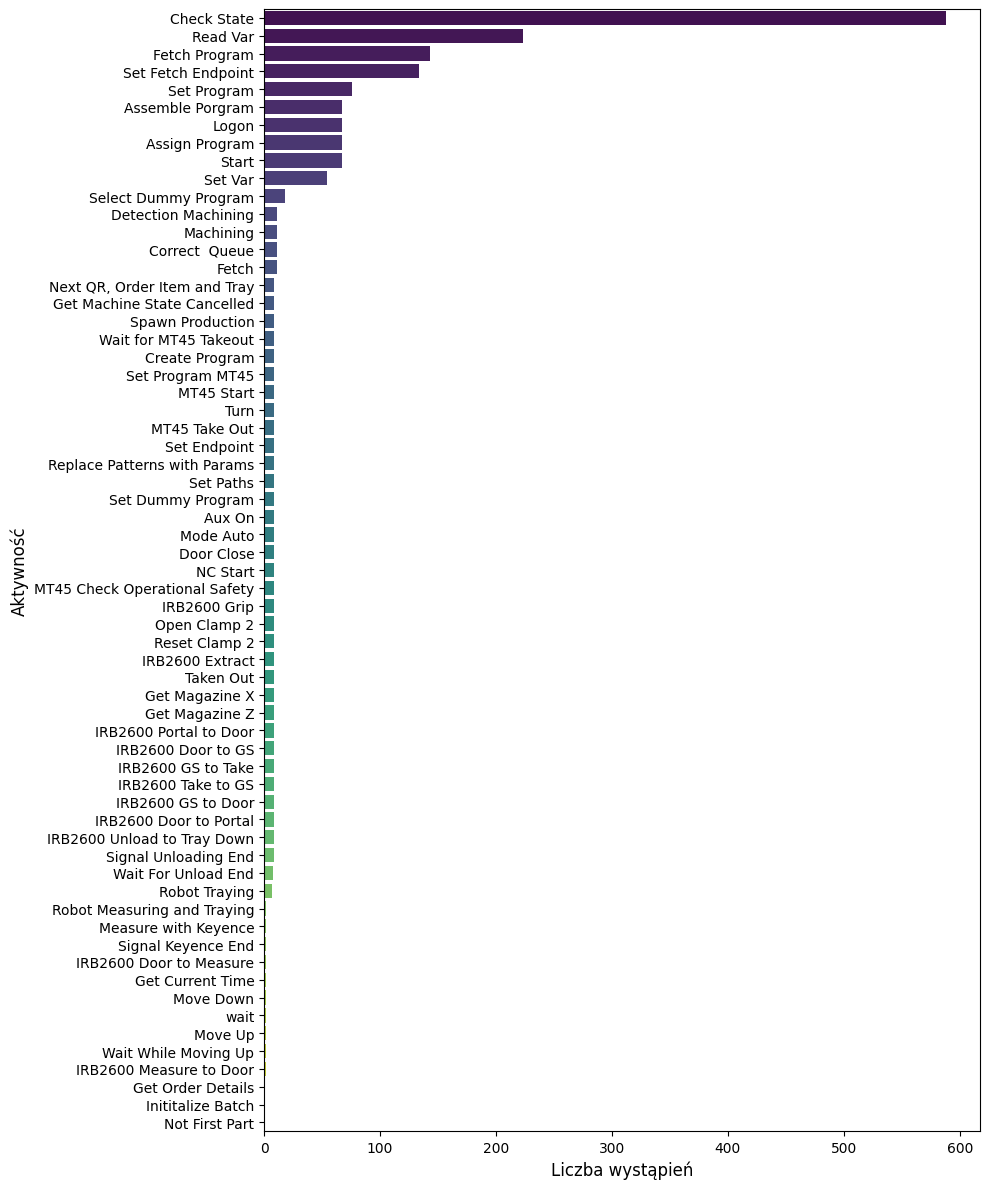

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

top_activities = df_clean['activity'].value_counts()
#
# For readability (OPTIONAL): Limit to top N activities
# top_n = 20
# top_activities = df_clean['activity'].value_counts().head(top_n)
# 

plt.figure(figsize=(10, 12)) 
sns.barplot(
    x=top_activities.values, 
    y=top_activities.index,
    palette="viridis"
)
plt.xlabel('Liczba wystąpień', fontsize=12)
plt.ylabel('Aktywność', fontsize=12)
plt.tight_layout()
plt.show()


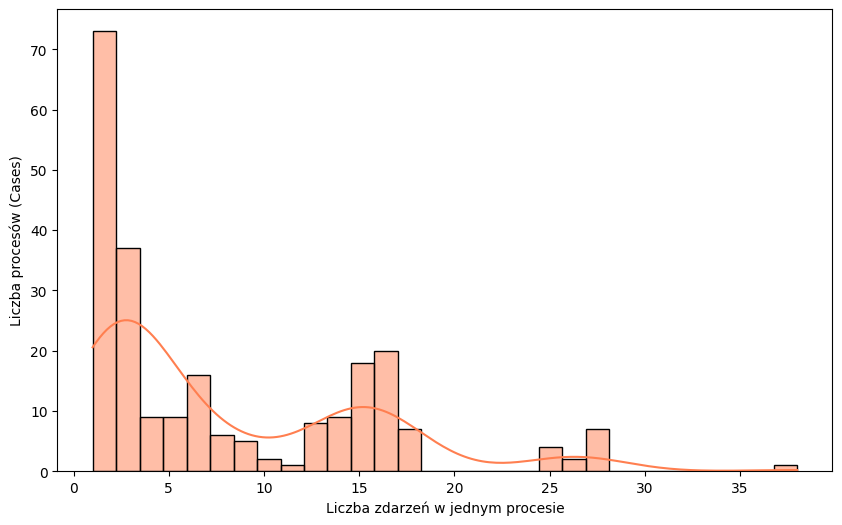

In [28]:

plt.figure(figsize=(10, 6))
events_per_case = df_clean.groupby('case_id').size()
sns.histplot(events_per_case, bins=30, kde=True, color="coral")
plt.xlabel('Liczba zdarzeń w jednym procesie')
plt.ylabel('Liczba procesów (Cases)')
plt.show()


In [15]:
# plt.figure(figsize=(12, 6))
# timeline_data = df_clean.set_index('timestamp').resample('h').size()
# timeline_data.plot(color="teal", linewidth=2.5)
# plt.xlabel('Czas')
# plt.ylabel('Liczba zdarzeń')
# plt.show()

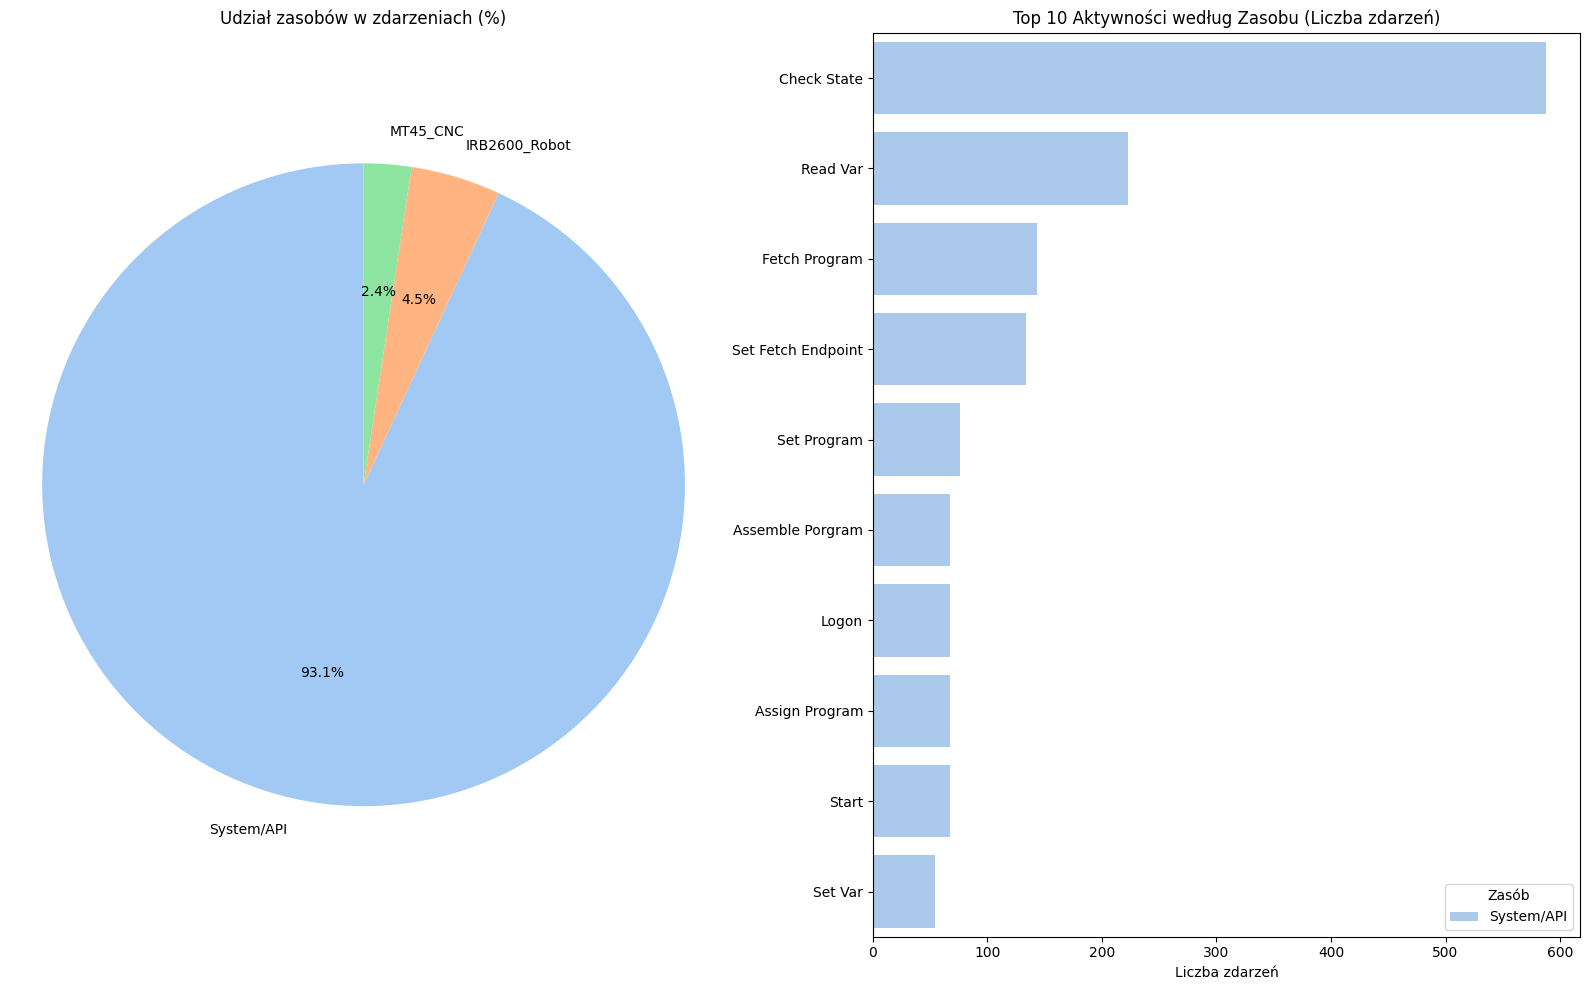

In [34]:
res_counts = df_clean['resource'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# Wykres kołowy
ax1.pie(res_counts, labels=res_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax1.axis('equal')
ax1.set_title('Udział zasobów w zdarzeniach (%)')

# Wykres słupkowy Top Aktywności per Zasób
# Bierzemy 3 główne zasoby
top_resources = res_counts.head(3).index
df_res_act = df_clean[df_clean['resource'].isin(top_resources)]

# Bierzemy top 10 aktywności ogólnie
top_acts = df_clean['activity'].value_counts().head(10).index
df_res_act = df_res_act[df_res_act['activity'].isin(top_acts)]

sns.countplot(data=df_res_act, y='activity', hue='resource', palette='pastel', ax=ax2, order=top_acts)
ax2.set_title('Top 10 Aktywności według Zasobu (Liczba zdarzeń)')
ax2.set_xlabel('Liczba zdarzeń')
ax2.set_ylabel('')
ax2.legend(title='Zasób')

plt.tight_layout()
plt.show()